In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ========================== 1. Load Data ==========================
df = pd.read_csv('laptop_price.csv', encoding="latin1")  # Change path if needed
print(f"Dataset shape: {df.shape}")

Dataset shape: (1303, 13)


In [6]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60



Missing values:
 laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

Price statistics:
 count    1303.000000
mean     1123.686992
std       699.009043
min       174.000000
25%       599.000000
50%       977.000000
75%      1487.880000
max      6099.000000
Name: Price_euros, dtype: float64


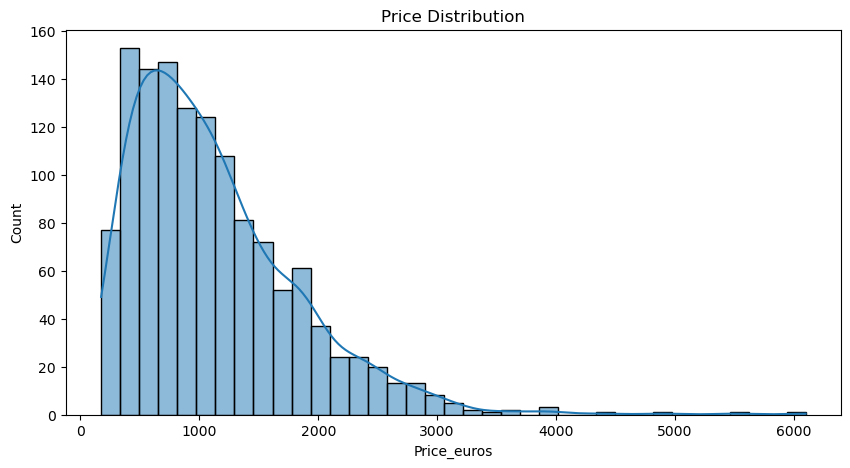

In [7]:
# ========================== 2. Basic EDA ==========================
print("\nMissing values:\n", df.isnull().sum())
print("\nPrice statistics:\n", df['Price_euros'].describe())

# Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_euros'], kde=True)
plt.title('Price Distribution')
plt.show()

In [8]:
# ========================== 3. Feature Engineering ==========================
def extract_features(df):
    # Extract RAM in GB
    df['Ram_GB'] = df['Ram'].str.extract('(\d+)').astype(int)
    
    # Extract Weight in kg
    df['Weight_kg'] = df['Weight'].str.extract('([\d.]+)').astype(float)
    
    # Extract CPU brand and speed
    df['Cpu_Brand'] = df['Cpu'].str.split().str[0]
    df['Cpu_Speed_GHz'] = df['Cpu'].str.extract('([\d.]+)GHz').astype(float)
    
    # Screen Resolution - extract width and height
    res = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
    df['Screen_Width'] = res[0].astype(float)
    df['Screen_Height'] = res[1].astype(float)
    df['Screen_Area'] = df['Screen_Width'] * df['Screen_Height']
    
    # Memory - simplify storage type
    df['Storage_Type'] = df['Memory'].str.contains('SSD').astype(int)  # 1 if has SSD
    
    return df

df = extract_features(df)

# Drop original complex columns and ID
drop_cols = ['laptop_ID', 'Product', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'Weight']
df = df.drop(columns=drop_cols, errors='ignore')

print("Features after engineering:", df.columns.tolist())

Features after engineering: ['Company', 'TypeName', 'Inches', 'OpSys', 'Price_euros', 'Ram_GB', 'Weight_kg', 'Cpu_Brand', 'Cpu_Speed_GHz', 'Screen_Width', 'Screen_Height', 'Screen_Area', 'Storage_Type']


In [9]:
# ========================== 4. Define X and y ==========================
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

In [10]:
# ========================== 5. Train-Test Split ==========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# ========================== 6. Preprocessing Pipeline ==========================
categorical_cols = ['Company', 'TypeName', 'OpSys', 'Cpu_Brand']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

In [12]:
# ========================== 7. Models ==========================
models = {
    'Ridge': Ridge(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

best_model = None
best_score = -np.inf
best_name = ""

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)  # R² score
    
    print(f"{name} R² score: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_model = pipeline
        best_name = name

print(f"\nBest model: {best_name} with R² = {best_score:.4f}")

Ridge R² score: 0.7549
RandomForest R² score: 0.8018
GradientBoosting R² score: 0.8296

Best model: GradientBoosting with R² = 0.8296


In [13]:
# ========================== 8. Hyperparameter Tuning (Best Model) ==========================
if best_name == 'RandomForest':
    param_grid = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 15]
    }
    grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print("Best params:", grid_search.best_params_)

In [15]:
# ========================== 9. Final Evaluation ==========================
y_pred = best_model.predict(X_test)

print("\nFinal Model Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} €")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

# Feature Importance (if tree-based)
if best_name in ['RandomForest', 'GradientBoosting']:
    importances = best_model.named_steps['model'].feature_importances_
    feature_names = (best_model.named_steps['preprocessor']
                     .get_feature_names_out())
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print("\nTop 10 Important Features:")
    print(feat_imp.head(10))


Final Model Performance:
MAE: 194.90 €
RMSE: 294.17 €
R² Score: 0.8296

Top 10 Important Features:
num__Ram_GB                  0.501749
cat__TypeName_Notebook       0.093468
num__Weight_kg               0.086654
num__Cpu_Speed_GHz           0.074229
num__Storage_Type            0.069608
num__Inches                  0.033785
num__Screen_Area             0.033267
cat__TypeName_Workstation    0.022130
cat__OpSys_Windows 7         0.017101
cat__Company_Razer           0.016862
dtype: float64


In [16]:
# ========================== 10. Save Model & Preprocessor ==========================
joblib.dump(best_model, 'laptop_price_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')   # For future use if needed

print("\n🎉 Model saved successfully as 'laptop_price_model.pkl'")


🎉 Model saved successfully as 'laptop_price_model.pkl'


In [17]:
# ========================== 11. Prediction Function ==========================
def predict_laptop_price(new_data):
    """new_data should be a DataFrame with same columns as original (except Price)"""
    model = joblib.load('laptop_price_model.pkl')
    return model.predict(new_data)

print("Prediction function ready!")

Prediction function ready!
